# Gap/Seam Detection Evaluation (Multi-Model)

This notebook evaluates how well segmentation models capture the **gaps/seams between stones**, comparing **all three model configurations** (3-channel, 4-channel, 7-channel) in a single run.

## Methodology:
The key insight is that morphological closing fills in gaps between stones. Therefore:
- `gaps = closed_mask - original_mask`

By comparing GT gaps against predicted gaps, we get a metric that directly measures stone boundary detection quality.

## Workflow:
1. **Set parameters** (paths for GT and all 3 predictions, kernel size)
2. **Generate ROI & extract gaps** from ground truth
3. **Extract gaps from all predictions** (within the ROI)
4. **Calculate gap-specific metrics** (IoU, precision, recall)
5. **Compare results** across models

---
## Cell 1: Parameters

Set your paths and kernel size here. Re-run subsequent cells after changing these.

In [25]:
# ============================================================
# PARAMETERS - EDIT THESE
# ============================================================

# Ground truth mask path
GT_MASK_PATH = r"C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\02_masks\Kaunos_Isodom_png-ortho.png"

# Prediction paths for all three models
PRED_PATHS = {
    '3-channel': r"C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\05_outputs\3-channel\Kauns_Isodom_png-DEM2_normalmap_RAW_combined_3ch.png",   # Geometry-only (normal maps)
    '4-channel': r"C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\05_outputs\4-channel\Kaunos_Isodom_png-ortho_RAW_combined_4ch.png",   # Appearance-only (RGB + alpha)
    '7-channel': r"C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\05_outputs\7-channel\Kaunos_Isodom_png-ortho_RAW_combined.png"    # Combined (RGB + alpha + normals)
}

# Output directory for results
OUTPUT_DIR = r"C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\08_ROI_Gap_evaluation\Wall4"

# Gap Detection Parameters
# ---------------------------
# Kernel size for morphological closing (in pixels)
# This should be large enough to bridge gaps between stones.
# The same kernel is used for both ROI generation and gap extraction.
# With gaps of 5-10cm and resolution of ~2-6 mm/px, gaps are roughly 8-60 pixels.
# A kernel of 40-60 pixels radius should work well.
KERNEL_RADIUS = 45  # Radius of the disk structuring element

# Model display colors for charts
MODEL_COLORS = {
    '3-channel': "#b41cb4",  # purple
    '4-channel': '#3498db',  # Blue
    '7-channel': '#2ecc71'   # Green
}

print(f"Ground Truth: {GT_MASK_PATH}")
print(f"\nPrediction Paths:")
for model_name, path in PRED_PATHS.items():
    print(f"  {model_name}: {path}")
print(f"\nOutput Dir: {OUTPUT_DIR}")
print(f"Kernel Radius: {KERNEL_RADIUS} pixels (diameter: {2*KERNEL_RADIUS + 1})")

Ground Truth: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\02_masks\Kaunos_Isodom_png-ortho.png

Prediction Paths:
  3-channel: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\05_outputs\3-channel\Kauns_Isodom_png-DEM2_normalmap_RAW_combined_3ch.png
  4-channel: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\05_outputs\4-channel\Kaunos_Isodom_png-ortho_RAW_combined_4ch.png
  7-channel: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\05_outputs\7-channel\Kaunos_Isodom_png-ortho_RAW_combined.png

Output Dir: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\08_ROI_Gap_evaluation\Wall4
Kernel Radius: 45 pixels (diameter: 91)


---
## Cell 2: Imports and Setup

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
import pandas as pd
from scipy import ndimage
from skimage.morphology import disk, binary_closing
from typing import Dict, Tuple
import os
import warnings
warnings.filterwarnings('ignore')

Image.MAX_IMAGE_PIXELS = None

# RGB to class mapping
RGB_TO_CLASS = {
    (0, 0, 0): 0,       # Black -> Background
    (0, 0, 255): 1,     # Blue -> Ashlar
    (255, 0, 0): 2,     # Red -> Polygonal
    (255, 255, 0): 3    # Yellow -> Quarry Stone
}

print("Imports complete.")

Imports complete.


---
## Cell 3: Helper Functions

In [27]:
def rgb_to_class_mask(rgb_image: np.ndarray, verbose: bool = True) -> np.ndarray:
    """
    Convert RGB mask to class indices.
    Handles unmapped colors by assigning to nearest class.
    """
    height, width = rgb_image.shape[:2]
    class_mask = np.zeros((height, width), dtype=np.uint8)
    
    for rgb_tuple, class_idx in RGB_TO_CLASS.items():
        color_mask = np.all(rgb_image == rgb_tuple, axis=2)
        class_mask[color_mask] = class_idx
    
    # Handle unmapped pixels (compression artifacts, anti-aliasing)
    mapped_pixels = np.zeros((height, width), dtype=bool)
    for rgb_tuple in RGB_TO_CLASS.keys():
        mapped_pixels |= np.all(rgb_image == rgb_tuple, axis=2)
    
    unmapped_count = np.sum(~mapped_pixels)
    if unmapped_count > 0 and verbose:
        print(f"    Note: {unmapped_count} pixels with unmapped colors -> mapped to nearest class")
        unmapped_indices = np.where(~mapped_pixels)
        for i in range(len(unmapped_indices[0])):
            y, x = unmapped_indices[0][i], unmapped_indices[1][i]
            pixel_rgb = rgb_image[y, x]
            min_dist = float('inf')
            nearest_class = 0
            for rgb_tuple, class_idx in RGB_TO_CLASS.items():
                dist = np.sqrt(np.sum((pixel_rgb.astype(float) - np.array(rgb_tuple).astype(float))**2))
                if dist < min_dist:
                    min_dist = dist
                    nearest_class = class_idx
            class_mask[y, x] = nearest_class
    
    return class_mask


def extract_gaps_via_closing(
    binary_mask: np.ndarray, 
    kernel_radius: int,
    roi_mask: np.ndarray = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extract gap pixels using morphological closing.
    
    Gaps are defined as pixels that:
    - Are 0 (background/gap) in the original binary mask
    - Become 1 (filled) after morphological closing
    
    Args:
        binary_mask: Binary mask (1=stone, 0=background/gap)
        kernel_radius: Radius of disk structuring element
        roi_mask: Optional ROI to restrict the operation
    
    Returns:
        Tuple of (closed_mask, gap_mask)
    """
    # Apply ROI if provided
    if roi_mask is not None:
        working_mask = binary_mask * roi_mask
    else:
        working_mask = binary_mask
    
    # Create structuring element
    selem = disk(kernel_radius)
    
    # Apply morphological closing
    closed_mask = binary_closing(working_mask.astype(bool), selem)
    
    # Extract gaps: pixels that were 0 but became 1 after closing
    gap_mask = closed_mask & ~working_mask.astype(bool)
    
    # If ROI was provided, ensure gaps are within ROI
    if roi_mask is not None:
        gap_mask = gap_mask & roi_mask
    
    return closed_mask, gap_mask


def calculate_gap_metrics(
    gt_gaps: np.ndarray, 
    pred_gaps: np.ndarray
) -> Dict[str, float]:
    """
    Calculate IoU, precision, recall, and F1 for gap detection.
    """
    gt_gaps = gt_gaps.astype(bool)
    pred_gaps = pred_gaps.astype(bool)
    
    # Basic counts
    gt_gap_pixels = np.sum(gt_gaps)
    pred_gap_pixels = np.sum(pred_gaps)
    
    # Intersection and union
    intersection = np.sum(gt_gaps & pred_gaps)
    union = np.sum(gt_gaps | pred_gaps)
    
    # IoU
    iou = intersection / union if union > 0 else 0.0
    
    # Precision: Of predicted gaps, how many are correct?
    precision = intersection / pred_gap_pixels if pred_gap_pixels > 0 else 0.0
    
    # Recall: Of GT gaps, how many were found?
    recall = intersection / gt_gap_pixels if gt_gap_pixels > 0 else 0.0
    
    # F1 Score
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'gap_iou': iou,
        'gap_precision': precision,
        'gap_recall': recall,
        'gap_f1': f1,
        'gt_gap_pixels': gt_gap_pixels,
        'pred_gap_pixels': pred_gap_pixels,
        'intersection_pixels': intersection,
        'union_pixels': union
    }


print("Helper functions defined.")

Helper functions defined.


---
## Cell 4: Load Ground Truth and Extract GT Gaps

In [28]:
# Load ground truth
print("Loading ground truth mask...")
gt_rgb = np.array(Image.open(GT_MASK_PATH).convert('RGB'))
gt_mask = rgb_to_class_mask(gt_rgb)
print(f"  Shape: {gt_mask.shape}")
print(f"  Classes present: {np.unique(gt_mask)}")

# Create binary mask (all stones -> 1, background -> 0)
gt_binary = (gt_mask > 0).astype(np.uint8)
print(f"  Stone pixels: {np.sum(gt_binary):,}")

# Generate ROI and GT gaps from ground truth
print(f"\nExtracting GT gaps with kernel radius = {KERNEL_RADIUS}...")
gt_closed, gt_gaps = extract_gaps_via_closing(gt_binary, KERNEL_RADIUS)

# The GT closed mask serves as our ROI
roi_mask = gt_closed.astype(bool)

print(f"  ROI pixels (GT closed): {np.sum(roi_mask):,}")
print(f"  GT gap pixels: {np.sum(gt_gaps):,}")

print("\n✓ Ground truth gaps extracted.")

Loading ground truth mask...
  Shape: (7880, 11225)
  Classes present: [0 1 2 3]
  Stone pixels: 30,538,608

Extracting GT gaps with kernel radius = 45...
  ROI pixels (GT closed): 31,731,691
  GT gap pixels: 1,193,083

✓ Ground truth gaps extracted.


---
## Cell 5: Load All Predictions and Extract Gaps

In [29]:
# Load all prediction masks and extract gaps
pred_masks = {}
pred_gaps_all = {}
pred_closed_all = {}

print("Loading predictions and extracting gaps...")
for model_name, pred_path in PRED_PATHS.items():
    print(f"\n  {model_name}:")
    
    # Load prediction
    pred_rgb = np.array(Image.open(pred_path).convert('RGB'))
    pred_mask = rgb_to_class_mask(pred_rgb, verbose=True)
    
    # Verify shape
    assert pred_mask.shape == gt_mask.shape, f"Shape mismatch: {pred_mask.shape} vs GT {gt_mask.shape}"
    
    pred_masks[model_name] = pred_mask
    
    # Create binary and extract gaps within ROI
    pred_binary = (pred_mask > 0).astype(np.uint8)
    pred_closed, pred_gaps = extract_gaps_via_closing(pred_binary, KERNEL_RADIUS, roi_mask)
    
    pred_closed_all[model_name] = pred_closed
    pred_gaps_all[model_name] = pred_gaps
    
    print(f"    Stone pixels (in ROI): {np.sum(pred_binary * roi_mask):,}")
    print(f"    Gap pixels: {np.sum(pred_gaps):,}")

print("\n✓ All predictions processed.")

Loading predictions and extracting gaps...

  3-channel:
    Stone pixels (in ROI): 28,812,496
    Gap pixels: 1,975,211

  4-channel:
    Stone pixels (in ROI): 29,656,653
    Gap pixels: 1,762,339

  7-channel:
    Stone pixels (in ROI): 29,061,845
    Gap pixels: 2,168,080

✓ All predictions processed.


---
## Cell 6: Calculate Gap Metrics for All Models

In [30]:
# Calculate gap metrics for each model
all_metrics = {}

print("Calculating gap detection metrics...\n")
print("="*70)

for model_name in PRED_PATHS.keys():
    print(f"\n{model_name.upper()}")
    print("-"*40)
    
    metrics = calculate_gap_metrics(gt_gaps, pred_gaps_all[model_name])
    all_metrics[model_name] = metrics
    
    print(f"  Gap IoU:        {metrics['gap_iou']:.4f}")
    print(f"  Gap Precision:  {metrics['gap_precision']:.4f}")
    print(f"  Gap Recall:     {metrics['gap_recall']:.4f}")
    print(f"  Gap F1-Score:   {metrics['gap_f1']:.4f}")
    print(f"  Pred gap pixels: {metrics['pred_gap_pixels']:,} (GT: {metrics['gt_gap_pixels']:,})")

print("\n" + "="*70)
print("✓ All gap metrics calculated.")

Calculating gap detection metrics...


3-CHANNEL
----------------------------------------
  Gap IoU:        0.3432
  Gap Precision:  0.4098
  Gap Recall:     0.6785
  Gap F1-Score:   0.5110
  Pred gap pixels: 1,975,211 (GT: 1,193,083)

4-CHANNEL
----------------------------------------
  Gap IoU:        0.4642
  Gap Precision:  0.5316
  Gap Recall:     0.7853
  Gap F1-Score:   0.6340
  Pred gap pixels: 1,762,339 (GT: 1,193,083)

7-CHANNEL
----------------------------------------
  Gap IoU:        0.4346
  Gap Precision:  0.4696
  Gap Recall:     0.8534
  Gap F1-Score:   0.6059
  Pred gap pixels: 2,168,080 (GT: 1,193,083)

✓ All gap metrics calculated.


---
## Cell 7: Comparative Summary Table

In [31]:
# Build comparative summary table
summary_data = []

for model_name in PRED_PATHS.keys():
    m = all_metrics[model_name]
    row = {
        'Model': model_name,
        'Gap_IoU': m['gap_iou'],
        'Gap_Precision': m['gap_precision'],
        'Gap_Recall': m['gap_recall'],
        'Gap_F1': m['gap_f1'],
        'GT_Gap_Pixels': m['gt_gap_pixels'],
        'Pred_Gap_Pixels': m['pred_gap_pixels'],
        'Gap_Ratio': m['pred_gap_pixels'] / m['gt_gap_pixels'] if m['gt_gap_pixels'] > 0 else 0
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)

# Display
print("\n" + "="*100)
print("GAP DETECTION COMPARATIVE SUMMARY")
print("="*100)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print("="*100)

# Highlight best model
best_model = summary_df.loc[summary_df['Gap_IoU'].idxmax(), 'Model']
best_iou = summary_df['Gap_IoU'].max()
print(f"\n→ Best gap detection: {best_model} (Gap IoU = {best_iou:.4f})")

# Interpretation
print("\nInterpretation (Gap Ratio = Predicted/GT):")
for _, row in summary_df.iterrows():
    ratio = row['Gap_Ratio']
    if ratio > 1.2:
        status = "OVER-SEGMENTS (more gaps than GT)"
    elif ratio < 0.8:
        status = "UNDER-SEGMENTS (fewer gaps than GT)"
    else:
        status = "BALANCED gap count"
    print(f"  {row['Model']}: ratio={ratio:.2f} → {status}")


GAP DETECTION COMPARATIVE SUMMARY
    Model  Gap_IoU  Gap_Precision  Gap_Recall  Gap_F1  GT_Gap_Pixels  Pred_Gap_Pixels  Gap_Ratio
3-channel   0.3432         0.4098      0.6785  0.5110        1193083          1975211     1.6556
4-channel   0.4642         0.5316      0.7853  0.6340        1193083          1762339     1.4771
7-channel   0.4346         0.4696      0.8534  0.6059        1193083          2168080     1.8172

→ Best gap detection: 4-channel (Gap IoU = 0.4642)

Interpretation (Gap Ratio = Predicted/GT):
  3-channel: ratio=1.66 → OVER-SEGMENTS (more gaps than GT)
  4-channel: ratio=1.48 → OVER-SEGMENTS (more gaps than GT)
  7-channel: ratio=1.82 → OVER-SEGMENTS (more gaps than GT)


---
## Cell 8: Visualize GT and All Predicted Gaps

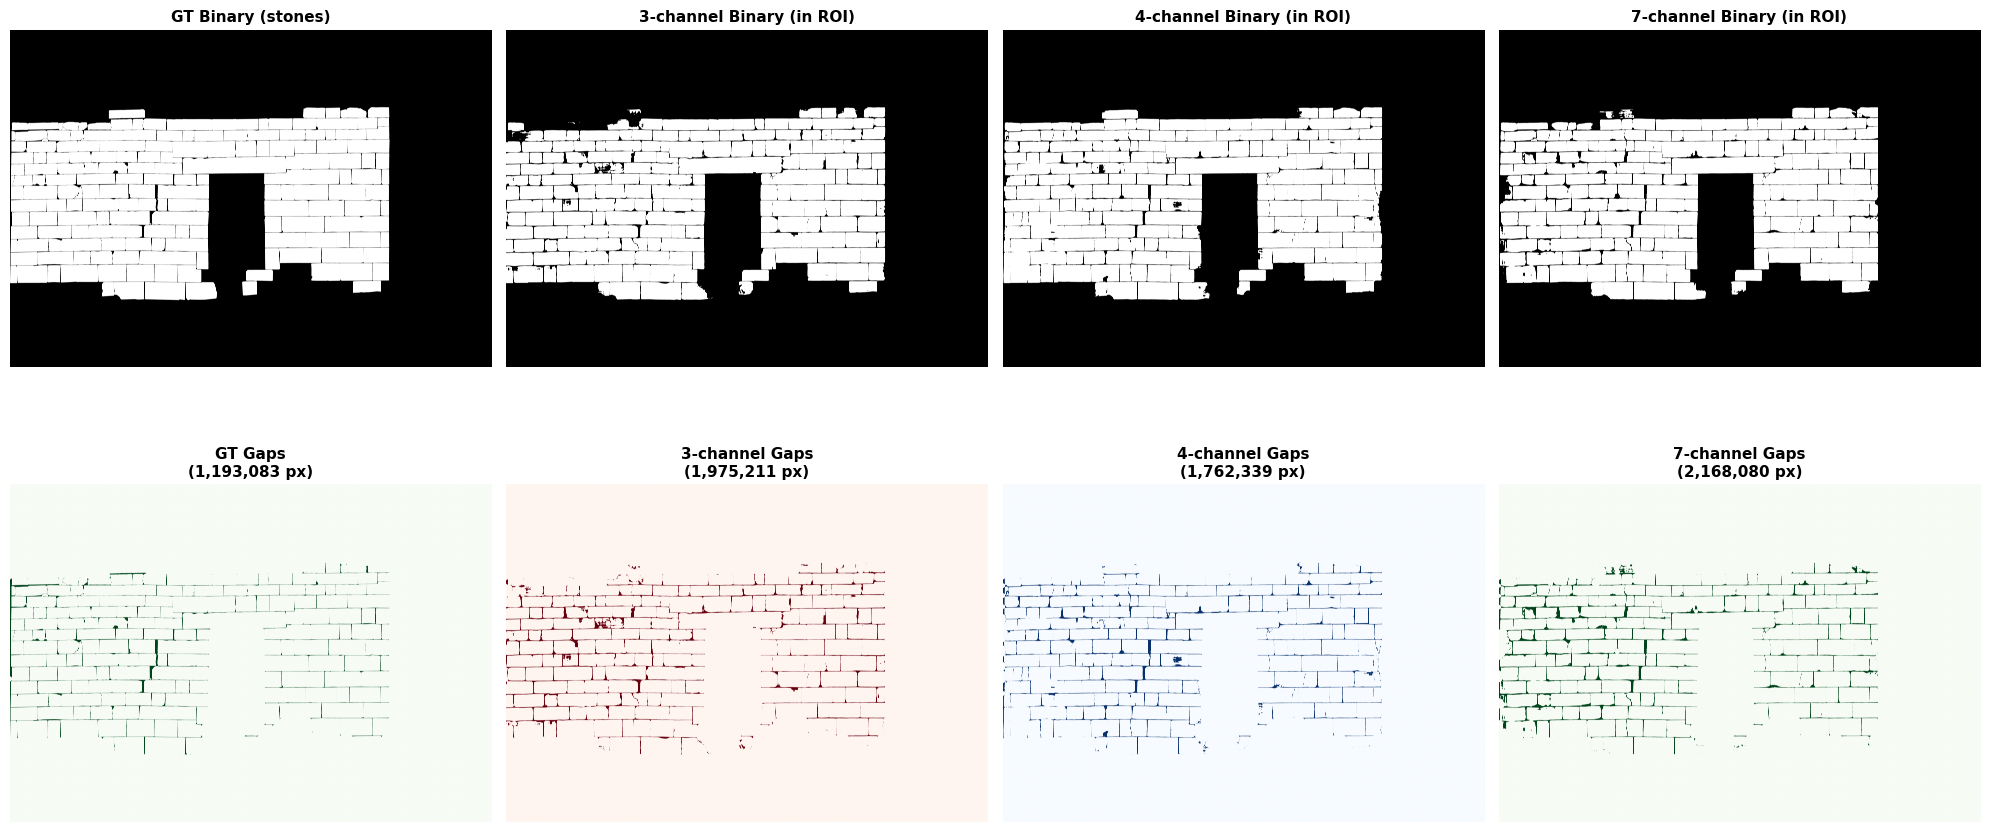

In [32]:
# Visualization of gap masks
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: Binary masks
axes[0, 0].imshow(gt_binary, cmap='gray')
axes[0, 0].set_title('GT Binary (stones)', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

for idx, model_name in enumerate(PRED_PATHS.keys()):
    pred_binary_roi = (pred_masks[model_name] > 0) * roi_mask
    axes[0, idx + 1].imshow(pred_binary_roi, cmap='gray')
    axes[0, idx + 1].set_title(f'{model_name} Binary (in ROI)', fontsize=11, fontweight='bold')
    axes[0, idx + 1].axis('off')

# Row 2: Gap masks
axes[1, 0].imshow(gt_gaps, cmap='Greens')
axes[1, 0].set_title(f'GT Gaps\n({np.sum(gt_gaps):,} px)', fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

gap_cmaps = {'3-channel': 'Reds', '4-channel': 'Blues', '7-channel': 'Greens'}
for idx, model_name in enumerate(PRED_PATHS.keys()):
    pred_gaps = pred_gaps_all[model_name]
    axes[1, idx + 1].imshow(pred_gaps, cmap=gap_cmaps.get(model_name, 'gray'))
    axes[1, idx + 1].set_title(f'{model_name} Gaps\n({np.sum(pred_gaps):,} px)', fontsize=11, fontweight='bold')
    axes[1, idx + 1].axis('off')

plt.tight_layout()
plt.show()

---
## Cell 9: Gap Overlap Comparison (All Models)

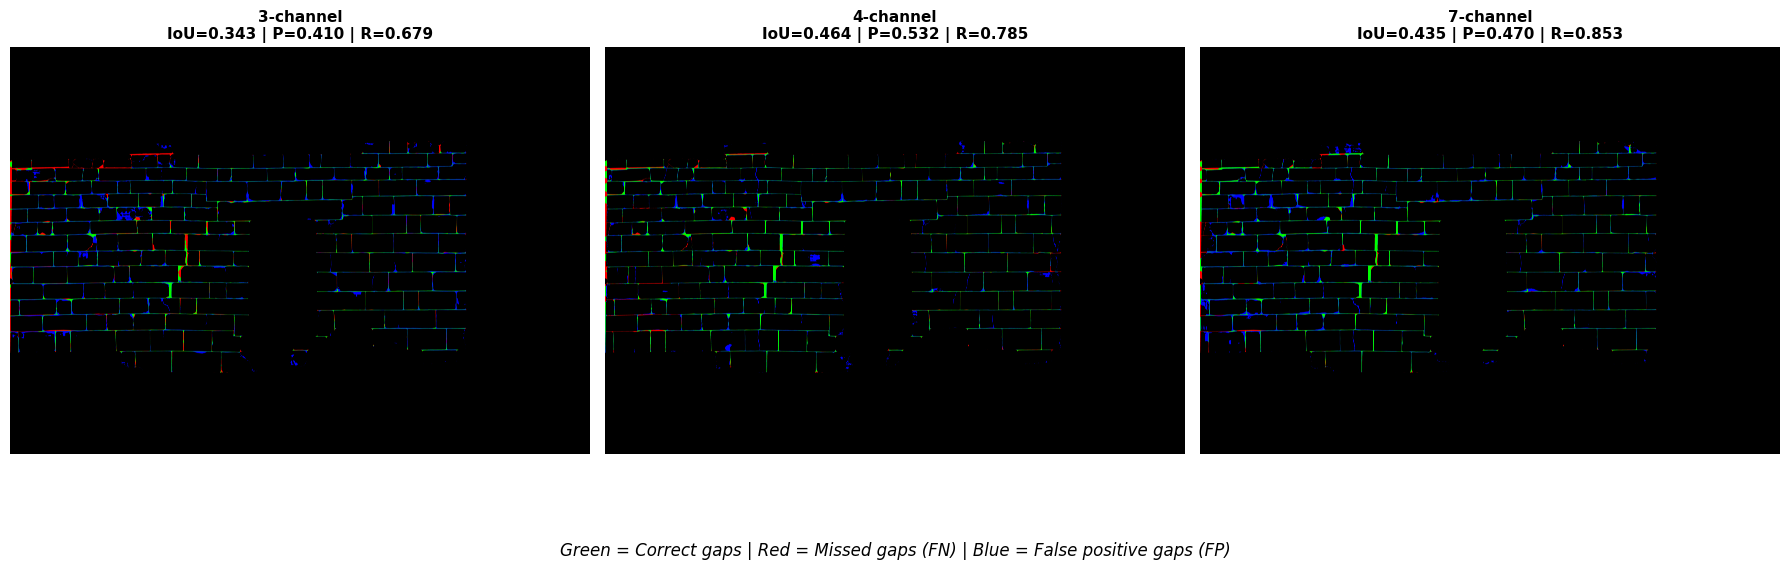

In [33]:
# Create overlap visualizations for each model
# Green = correct (intersection), Red = missed, Blue = false positive

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

gt_gaps_bool = gt_gaps.astype(bool)

for idx, model_name in enumerate(PRED_PATHS.keys()):
    pred_gaps_bool = pred_gaps_all[model_name].astype(bool)
    
    # Classification
    correct_gaps = gt_gaps_bool & pred_gaps_bool      # True positive
    missed_gaps = gt_gaps_bool & ~pred_gaps_bool      # False negative
    false_pos_gaps = ~gt_gaps_bool & pred_gaps_bool   # False positive
    
    # Create RGB visualization
    overlap_viz = np.zeros((*gt_gaps.shape, 3), dtype=np.uint8)
    overlap_viz[correct_gaps] = [0, 255, 0]        # Green
    overlap_viz[missed_gaps] = [255, 0, 0]         # Red
    overlap_viz[false_pos_gaps] = [0, 0, 255]      # Blue
    
    axes[idx].imshow(overlap_viz)
    
    m = all_metrics[model_name]
    axes[idx].set_title(f'{model_name}\nIoU={m["gap_iou"]:.3f} | P={m["gap_precision"]:.3f} | R={m["gap_recall"]:.3f}',
                        fontsize=11, fontweight='bold')
    axes[idx].axis('off')

# Add legend
fig.text(0.5, 0.02, 'Green = Correct gaps | Red = Missed gaps (FN) | Blue = False positive gaps (FP)',
         ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

---
## Cell 10: Comparative Gap Metrics Bar Chart

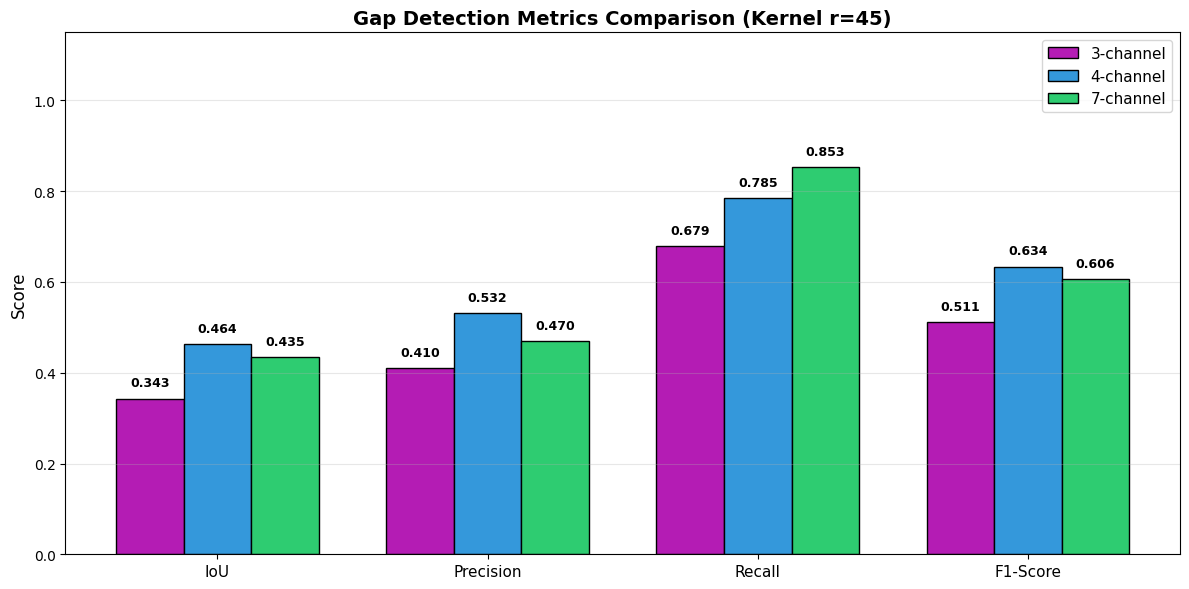

In [34]:
# Grouped bar chart comparing gap metrics across models
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_plot = ['gap_iou', 'gap_precision', 'gap_recall', 'gap_f1']
metric_labels = ['IoU', 'Precision', 'Recall', 'F1-Score']

x = np.arange(len(metric_labels))
width = 0.25
multiplier = 0

for model_name in PRED_PATHS.keys():
    values = [all_metrics[model_name][m] for m in metrics_to_plot]
    offset = width * multiplier
    bars = ax.bar(x + offset, values, width, 
                  label=model_name, color=MODEL_COLORS[model_name],
                  edgecolor='black', linewidth=1)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    multiplier += 1

ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Gap Detection Metrics Comparison (Kernel r={KERNEL_RADIUS})', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Cell 11: Gap IoU Summary Chart

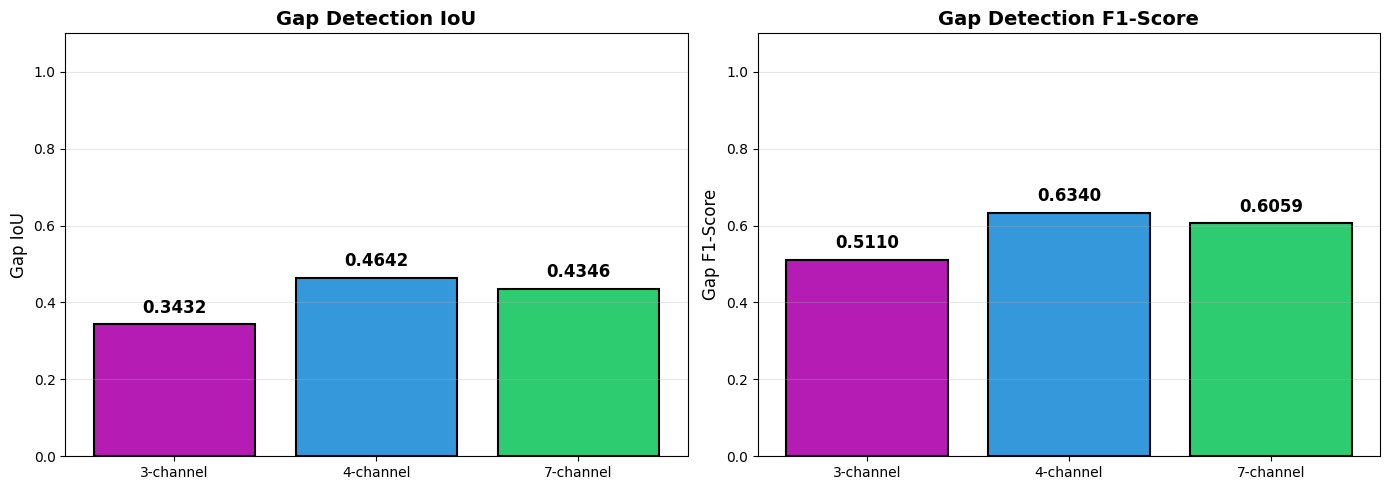

In [35]:
# Simple bar chart for gap IoU comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(PRED_PATHS.keys())
gap_ious = [all_metrics[m]['gap_iou'] for m in model_names]
gap_f1s = [all_metrics[m]['gap_f1'] for m in model_names]
colors = [MODEL_COLORS[m] for m in model_names]

# Gap IoU
bars1 = axes[0].bar(model_names, gap_ious, color=colors, edgecolor='black', linewidth=1.5)
for bar, val in zip(bars1, gap_ious):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Gap IoU', fontsize=12)
axes[0].set_title('Gap Detection IoU', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Gap F1
bars2 = axes[1].bar(model_names, gap_f1s, color=colors, edgecolor='black', linewidth=1.5)
for bar, val in zip(bars2, gap_f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Gap F1-Score', fontsize=12)
axes[1].set_title('Gap Detection F1-Score', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Cell 12: Save Results

In [36]:
# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save summary table
summary_path = os.path.join(OUTPUT_DIR, 'gap_evaluation_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f"✓ Summary table saved to: {summary_path}")

# Save GT gaps mask
gt_gaps_path = os.path.join(OUTPUT_DIR, 'gt_gaps.png')
Image.fromarray((gt_gaps * 255).astype(np.uint8)).save(gt_gaps_path)
print(f"✓ GT gaps mask saved to: {gt_gaps_path}")

# Save predicted gap masks and overlap visualizations for each model
for model_name in PRED_PATHS.keys():
    # Gap mask
    pred_gaps = pred_gaps_all[model_name]
    gap_path = os.path.join(OUTPUT_DIR, f'pred_gaps_{model_name.replace("-", "_")}.png')
    Image.fromarray((pred_gaps * 255).astype(np.uint8)).save(gap_path)
    print(f"✓ {model_name} gaps saved to: {gap_path}")
    
    # Overlap visualization
    pred_gaps_bool = pred_gaps.astype(bool)
    overlap_viz = np.zeros((*gt_gaps.shape, 3), dtype=np.uint8)
    overlap_viz[gt_gaps_bool & pred_gaps_bool] = [0, 255, 0]
    overlap_viz[gt_gaps_bool & ~pred_gaps_bool] = [255, 0, 0]
    overlap_viz[~gt_gaps_bool & pred_gaps_bool] = [0, 0, 255]
    
    overlap_path = os.path.join(OUTPUT_DIR, f'gap_overlap_{model_name.replace("-", "_")}.png')
    Image.fromarray(overlap_viz).save(overlap_path)
    print(f"✓ {model_name} overlap saved to: {overlap_path}")

print("\n✓ All results saved.")

✓ Summary table saved to: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\08_ROI_Gap_evaluation\Wall4\gap_evaluation_summary.csv
✓ GT gaps mask saved to: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\08_ROI_Gap_evaluation\Wall4\gt_gaps.png
✓ 3-channel gaps saved to: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\08_ROI_Gap_evaluation\Wall4\pred_gaps_3_channel.png
✓ 3-channel overlap saved to: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\08_ROI_Gap_evaluation\Wall4\gap_overlap_3_channel.png
✓ 4-channel gaps saved to: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\08_ROI_Gap_evaluation\Wall4\pred_gaps_4_channel.png
✓ 4-channel overlap saved to: C:\Users\admin\Desktop\OrdnerAmGArtikel2025\AWS_TRAINING\2025-08-10_4classEX\testing\08_ROI_Gap_evaluation\Wall4\gap_overlap_4_channel.png
✓ 7-channel gaps s